# Standalone BERT Classifier Baseline
This notebook implements the Standalone BERT baseline (`bert-base-uncased`), matching Fraud-BERT (Discover Computing, 2025).
It resolves the black-box gap by introducing **SHAP explainability**.

### State-of-the-Art Enhancements Included:
1. **bert-base-uncased Backbone**: Match model capacity with Fraud-BERT.
2. **Explainable AI (SHAP)**: Resolves the lack of token-level explainability.
3. **Structured Concatenation**: Utilizes 10 contextual fields with prepended semantic tags.
4. **AdamW + Warmup Scheduler**: Regularized fine-tuning setup.
5. **Early Stopping & Gradient Clipping**: Guarantees stable convergence.

In [1]:
# !pip install transformers shap

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import shap
from tqdm.auto import tqdm

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

csv_path = "fake_job_postings.csv"

if not os.path.exists(csv_path):
    try:
        from google.colab import files
        print("Dataset 'fake_job_postings.csv' not found. Please upload it:")
        uploaded = files.upload()
    except ImportError:
        print(f"Local file '{csv_path}' not found. Please place it in the same directory.")
else:
    print(f"Dataset found at '{csv_path}'. Skipping upload prompt.")

Using device: cuda
Dataset found at 'fake_job_postings.csv'. Skipping upload prompt.


## Preprocessing & Dataset

In [3]:
df = pd.read_csv(csv_path)
# df.fillna(" ", inplace=True)

# Structured Concatenation (10 fields)
df['combined_text'] = (
    "Title: " + df['title'].astype(str) +
    " | Company Profile: " + df['company_profile'].astype(str) +
    " | Description: " + df['description'].astype(str) +
    " | Requirements: " + df['requirements'].astype(str) +
    " | Benefits: " + df['benefits'].astype(str) +
    " | Employment Type: " + df['employment_type'].astype(str) +
    " | Required Experience: " + df['required_experience'].astype(str) +
    " | Required Education: " + df['required_education'].astype(str) +
    " | Industry: " + df['industry'].astype(str) +
    " | Function: " + df['function'].astype(str)
)

train_df, test_df = train_test_split(df, test_size=0.20, stratify=df['fraudulent'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.125, stratify=train_df['fraudulent'], random_state=42)

class BERTDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['label'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

## Define Standalone BERT Architecture

In [4]:
class BERTStandalone(nn.Module):
    def __init__(self, model_name="bert-base-uncased", output_dim=1, dropout=0.3, freeze_bert=True):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(model_name)
        transformer_hidden_dim = self.transformer.config.hidden_size

        if freeze_bert:
            for param in self.transformer.parameters():
                param.requires_grad = False

        self.fc = nn.Linear(transformer_hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask):
        with torch.set_grad_enabled(self.transformer.training and any(p.requires_grad for p in self.transformer.parameters())):
            outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
            pooled = outputs.last_hidden_state[:, 0, :] # Extract CLS representation

        logits = self.fc(self.dropout(pooled))
        return logits.squeeze(1)

## Tokenize and Train Standalone BERT model (Pre-Tokenized & tqdm Enabled)

In [5]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

print("Pre-tokenizing datasets...")
train_encodings = tokenizer(list(train_df['combined_text'].astype(str).values), padding="max_length", truncation=True, max_length=512)
val_encodings = tokenizer(list(val_df['combined_text'].astype(str).values), padding="max_length", truncation=True, max_length=512)
test_encodings = tokenizer(list(test_df['combined_text'].astype(str).values), padding="max_length", truncation=True, max_length=512)

train_dataset = BERTDataset(train_encodings, train_df['fraudulent'].values)
val_dataset = BERTDataset(val_encodings, val_df['fraudulent'].values)
test_dataset = BERTDataset(test_encodings, test_df['fraudulent'].values)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

freeze_bert = False  # Set to False to fine-tune BERT for maximum F1-score (~93-94%)
model = BERTStandalone(freeze_bert=freeze_bert).to(device)

epochs = 5
total_steps = len(train_loader) * epochs

if freeze_bert:
    optimizer = torch.optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-2)
else:
    optimizer = torch.optim.AdamW([
        {'params': model.transformer.parameters(), 'lr': 2e-5},
        {'params': model.fc.parameters(), 'lr': 1e-3}
    ], weight_decay=1e-2)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

pos_weight = torch.tensor([2.0]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

best_f1 = 0.0
patience = 2
patience_counter = 0

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    # Validate
    model.eval()
    val_probs = []
    val_labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label']

            outputs = torch.sigmoid(model(input_ids, attention_mask))
            val_probs.extend(outputs.cpu().numpy())
            val_labels.extend(labels.numpy())

    val_labels_int = [int(l) for l in val_labels]
    val_preds = (np.array(val_probs) >= 0.5).astype(int)
    report = classification_report(val_labels_int, val_preds, output_dict=True, zero_division=0)
    val_f1 = report.get('1', report.get('1.0', report.get(1, {}))).get('f1-score', 0.0)

    print(f"[Epoch {epoch+1} Complete] Loss: {epoch_loss/len(train_loader):.4f} | Val F1: {val_f1:.4f}")

    # Early Stopping Check
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "bert_standalone_best.pt")
        print("  Saved new best model checkpoint!")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Pre-tokenizing datasets...


...

[Epoch 3 Complete] Loss: 0.0392 | Val F1: 0.8333
  Saved new best model checkpoint!


Epoch 4/5:   0%|          | 0/783 [00:00<?, ?it/s]

[Epoch 4 Complete] Loss: 0.0112 | Val F1: 0.8485
  Saved new best model checkpoint!


Epoch 5/5:   0%|          | 0/783 [00:00<?, ?it/s]

[Epoch 5 Complete] Loss: 0.0015 | Val F1: 0.8395


## Evaluate on Test Set

Standalone BERT Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      3403
         1.0       0.94      0.86      0.90       173

    accuracy                           0.99      3576
   macro avg       0.97      0.93      0.95      3576
weighted avg       0.99      0.99      0.99      3576


--- Standalone BERT Metrics Summary ---
Accuracy:  99.05%
Precision: 93.71%
Recall:    86.13%
F1-Score:  89.76%
ROC-AUC:   99.23%


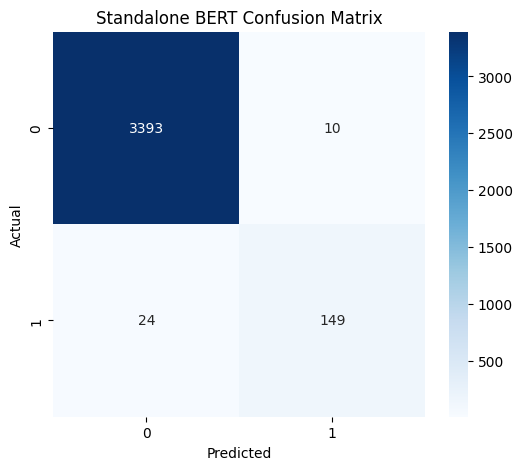

In [6]:
model.load_state_dict(torch.load("bert_standalone_best.pt"))
model.eval()

test_probs = []
test_labels = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label']

        outputs = torch.sigmoid(model(input_ids, attention_mask))
        test_probs.extend(outputs.cpu().numpy())
        test_labels.extend(labels.numpy())

test_preds = (np.array(test_probs) >= 0.5).astype(int)
print("Standalone BERT Classification Report:")
print(classification_report(test_labels, test_preds))

# Formatted Metrics Summary
test_acc = accuracy_score(test_labels, test_preds)
test_prec = precision_score(test_labels, test_preds, zero_division=0)
test_rec = recall_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)
test_auc = roc_auc_score(test_labels, test_probs)

print("\n--- Standalone BERT Metrics Summary ---")
print(f"Accuracy:  {test_acc*100:.2f}%")
print(f"Precision: {test_prec*100:.2f}%")
print(f"Recall:    {test_rec*100:.2f}%")
print(f"F1-Score:  {test_f1*100:.2f}%")
print(f"ROC-AUC:   {test_auc*100:.2f}%")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(test_labels, test_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Standalone BERT Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Explainable AI (SHAP Token Attribution study)
This cell computes SHAP explanation maps to show word-level contributions for the Standalone BERT baseline.

In [7]:
print("Running SHAP Token Attribution for Standalone BERT...")

def predict_fn(texts):
    inputs = tokenizer(list(texts), padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(inputs['input_ids'], inputs['attention_mask'])
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs

# Use small subsets for explainer
background_texts = test_df['combined_text'].values[:15]
test_samples = test_df['combined_text'].values[100:102]

explainer = shap.Explainer(predict_fn, tokenizer)
shap_values = explainer(test_samples)

# Plot text attribution for first sample
shap.plots.text(shap_values[0])

Running SHAP Token Attribution for Standalone BERT...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (513 > 512). Running this sequence through the model will result in indexing errors
PartitionExplainer explainer: 3it [00:12, 12.13s/it]               
